# Task 4: Supervised Contrastive Loss


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "pyproject.toml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from pytorch_metric_learning import losses
from tqdm.auto import tqdm

from src.task4.config import (
    CONFIG_DIR,
    EARLY_STOPPING_PATIENCE,
    FINAL_EPOCHS,
    HISTORY_DIR,
    IMAGE_DIR,
    INPUT_SIZE,
    LABEL_COLUMN,
    LABEL_ID_COLUMN,
    MIN_CLASS_SIZE,
    MIN_DELTA,
    MODEL_DIR,
    N_TRIALS,
    PLOT_DIR,
    SEED,
    SPLIT_DIR,
    TUNING_EPOCHS,
    VAL_FRACTION,
)
from src.task4.data import (
    make_evaluation_loader,
    make_model_loaders,
    make_validation_loss_loader,
)
from src.task4.models import ResNet18Encoder
from src.task4.preprocessing import (
    cae_transform,
    metric_eval_transform,
    metric_preprocessing_config,
    metric_train_transform,
)
from src.task4.retrieval import (
    evaluate_retrieval,
    extract_embeddings,
    k_reciprocal_rerank,
    retrieval_metrics,
    search_cosine,
)
from src.task4.training import (
    AMP_ENABLED,
    DEVICE,
    EarlyStopping,
    cpu_state_dict,
    evaluate_loss,
    new_optimizer_and_scheduler,
    set_seed,
    train_one_epoch,
)
from src.task4.tuning import create_study, load_best_params, suggest_parameters


## Data preparation and validation split


In [3]:
set_seed(SEED)
print("Device:", DEVICE, "| Mixed precision:", AMP_ENABLED)


Device: cuda | Mixed precision: True


In [ ]:
outer_train_df = pd.read_csv(SPLIT_DIR / "train.csv")
with (CONFIG_DIR / "articleType_gender_label_encoder.json").open(
    encoding="utf-8"
) as file:
    label_encoder_config = json.load(file)

classes = label_encoder_config["classes"]
label_to_index = label_encoder_config["label_to_index"]

outer_train_df[LABEL_COLUMN] = (
    outer_train_df["articleType"].str.strip()
    + "__"
    + outer_train_df["gender"].str.strip()
)

outer_train_df[LABEL_ID_COLUMN] = (
    outer_train_df[LABEL_COLUMN].map(label_to_index).astype("int64")
)

outer_class_counts = outer_train_df[LABEL_COLUMN].value_counts()
eligible_labels = set(outer_class_counts[outer_class_counts >= MIN_CLASS_SIZE].index)
development_df = outer_train_df[
    outer_train_df[LABEL_COLUMN].isin(eligible_labels)
].copy()


In [ ]:
inner_stratify_columns = ["articleType", "gender"]
inner_stratify_features = pd.get_dummies(
    development_df[inner_stratify_columns].astype(str),
    prefix=inner_stratify_columns,
)
inner_splitter = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=VAL_FRACTION,
    random_state=SEED,
)
inner_train_idx, inner_val_idx = next(
    inner_splitter.split(development_df, inner_stratify_features)
)
train_df = development_df.iloc[inner_train_idx].copy()
val_df = development_df.iloc[inner_val_idx].copy()

train_counts = train_df[LABEL_ID_COLUMN].value_counts()
valid_label_ids = train_counts[train_counts >= MIN_CLASS_SIZE].index
train_df = train_df[train_df[LABEL_ID_COLUMN].isin(valid_label_ids)].copy()
val_df = val_df[val_df[LABEL_ID_COLUMN].isin(valid_label_ids)].copy()

overlap = set(train_df["id"]) & set(val_df["id"])
if overlap:
    raise ValueError(f"Inner split contains {len(overlap)} overlapping IDs")
if val_df[LABEL_ID_COLUMN].isna().any():
    raise ValueError("Inner validation contains an unmapped label")


In [6]:
gallery_parts = []
for _, group in train_df.groupby(LABEL_COLUMN, sort=True):
    sample_size = min(20, len(group))
    gallery_parts.append(group.sample(sample_size, random_state=SEED))

tuning_gallery_df = pd.concat(gallery_parts).sort_values("id").reset_index(drop=True)

print(f"Model train/validation: {len(train_df):,}/{len(val_df):,}")
print("Excluded rare rows:", len(outer_train_df) - len(development_df))
print("Tuning gallery rows:", len(tuning_gallery_df))

Model train/validation: 30,389/3,378
Excluded rare rows: 153
Tuning gallery rows: 2861


## Hyperparameter tuning


In [ ]:
def supcon_objective(trial: optuna.Trial):
    parameters = suggest_parameters(trial, "supcon")
    set_seed(SEED)
    model = ResNet18Encoder()
    loss_function = losses.SupConLoss(temperature=parameters.get("temperature", 0.1))
    model, loss_function = model.to(DEVICE), loss_function.to(DEVICE)
    loaders = make_model_loaders(
        "supcon",
        train_df,
        tuning_gallery_df,
        val_df,
        cae_transform,
        metric_train_transform,
        metric_eval_transform,
        IMAGE_DIR,
    )
    optimizer, scheduler = new_optimizer_and_scheduler(model, parameters)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    best_score = -math.inf
    for epoch in tqdm(range(1, TUNING_EPOCHS + 1), desc="supcon tuning"):
        train_one_epoch(
            "supcon", model, loss_function, loaders["train"], optimizer, scaler, epoch
        )
        score = evaluate_retrieval(model, loaders["gallery"], loaders["query"])[
            "mAP@10"
        ]
        scheduler.step(score)
        best_score = max(best_score, score)
        trial.report(score, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_score

In [ ]:
supcon_study = create_study("task4_supcon")
supcon_study.optimize(supcon_objective, n_trials=N_TRIALS)

print("supcon", "best parameters:", supcon_study.best_params)
print("supcon", "tuned validation mAP@10:", supcon_study.best_value)


[I 2026-09-07 02:16:08,022] A new study created in RDB with name: task4_supcon


supcon tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-07 02:20:41,416] Trial 0 finished with value: 0.3583569415859232 and parameters: {'learning_rate': 0.00011155792840695785, 'weight_decay': 0.0002264824818951685, 'temperature': 0.175}. Best is trial 0 with value: 0.3583569415859232.


supcon tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-07 02:25:06,132] Trial 1 finished with value: 0.4682389234913534 and parameters: {'learning_rate': 0.00024479668704186603, 'weight_decay': 2.434877353455462e-06, 'temperature': 0.07500000000000001}. Best is trial 1 with value: 0.4682389234913534.


...

supcon tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-07 03:12:46,586] Trial 18 pruned. 


supcon tuning:   0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-07 03:13:52,014] Trial 19 pruned. 


supcon best parameters: {'learning_rate': 0.00024479668704186603, 'weight_decay': 2.434877353455462e-06, 'temperature': 0.07500000000000001}


## Final training


In [9]:
supcon_history = []
supcon_best_epoch = 0
supcon_best_score = -math.inf

supcon_best_params, supcon_tuning_best_value = load_best_params("task4_supcon")
print("supcon loaded Optuna best parameters:", supcon_best_params)
print("supcon tuned validation mAP@10:", supcon_tuning_best_value)

parameters = supcon_best_params
set_seed(SEED)
model = ResNet18Encoder()
loss_function = losses.SupConLoss(temperature=parameters.get("temperature", 0.1))
model, loss_function = model.to(DEVICE), loss_function.to(DEVICE)
loaders = make_model_loaders(
    "supcon",
    train_df,
    tuning_gallery_df,
    val_df,
    cae_transform,
    metric_train_transform,
    metric_eval_transform,
    IMAGE_DIR,
)
val_loss_loader = make_validation_loss_loader(
    "supcon", val_df, cae_transform, metric_eval_transform, IMAGE_DIR
)


In [10]:
optimizer, scheduler = new_optimizer_and_scheduler(model, parameters)
scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
stopper = EarlyStopping(EARLY_STOPPING_PATIENCE, MIN_DELTA)
best_state = None


In [11]:
for epoch in tqdm(range(1, FINAL_EPOCHS + 1), desc="supcon final"):
    train_loss = train_one_epoch(
        "supcon", model, loss_function, loaders["train"], optimizer, scaler, epoch
    )
    val_loss = evaluate_loss("supcon", model, loss_function, val_loss_loader)
    metrics = evaluate_retrieval(model, loaders["gallery"], loaders["query"])
    score = metrics["mAP@10"]
    scheduler.step(score)
    if stopper.update(score):
        best_state = cpu_state_dict(model)
        supcon_best_epoch = epoch
    supcon_history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_map_at_10": score,
        }
    )
    print("supcon", epoch, "loss:", round(train_loss, 4), "mAP@10:", round(score, 4))
    if stopper.should_stop:
        break


supcon final:   0%|          | 0/60 [00:00<?, ?it/s]

supcon 1 loss: 3.0214 mAP@10: 0.1875
supcon 2 loss: 2.5722 mAP@10: 0.2141
supcon 3 loss: 2.4435 mAP@10: 0.2507
supcon 4 loss: 2.3618 mAP@10: 0.265
supcon 5 loss: 2.3062 mAP@10: 0.3008
supcon 6 loss: 2.2674 mAP@10: 0.3021
supcon 7 loss: 2.246 mAP@10: 0.332
supcon 8 loss: 2.2124 mAP@10: 0.3426
supcon 9 loss: 2.1975 mAP@10: 0.3558
supcon 10 loss: 2.1759 mAP@10: 0.3753
supcon 11 loss: 2.1577 mAP@10: 0.388
supcon 12 loss: 2.1525 mAP@10: 0.3909
supcon 13 loss: 2.1378 mAP@10: 0.3961
supcon 14 loss: 2.1348 mAP@10: 0.4112
supcon 15 loss: 2.1146 mAP@10: 0.4298
supcon 16 loss: 2.117 mAP@10: 0.4251
supcon 17 loss: 2.1153 mAP@10: 0.442
supcon 18 loss: 2.1024 mAP@10: 0.3919
supcon 19 loss: 2.0891 mAP@10: 0.4556
supcon 20 loss: 2.0888 mAP@10: 0.4644
supcon 21 loss: 2.0842 mAP@10: 0.4783
supcon 22 loss: 2.0782 mAP@10: 0.4957
supcon 23 loss: 2.0729 mAP@10: 0.4854
supcon 24 loss: 2.0623 mAP@10: 0.5006
supcon 25 loss: 2.0647 mAP@10: 0.4948
supcon 26 loss: 2.0559 mAP@10: 0.5276
supcon 27 loss: 2.057 mAP@1

In [12]:
model.load_state_dict(best_state)
supcon_best_score = stopper.best_score
supcon_model = model
print("supcon", "best epoch:", supcon_best_epoch, "best mAP@10:", supcon_best_score)


supcon best epoch: 60 best mAP@10: 0.699143571381582


## Training history and learning curves


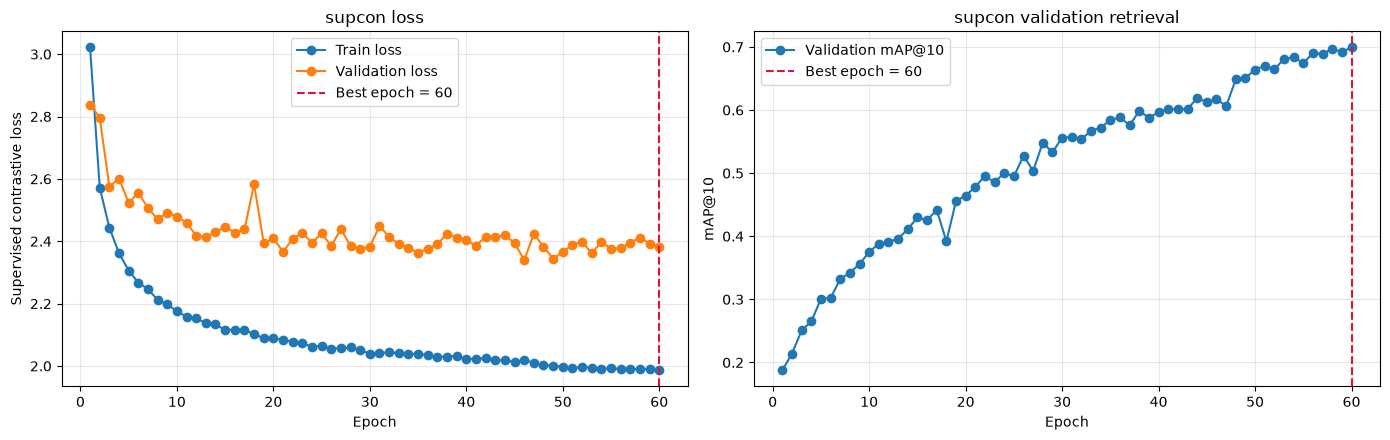

In [13]:
HISTORY_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

history_path = HISTORY_DIR / "supcon_history.csv"
pd.DataFrame(supcon_history).sort_values("epoch").to_csv(history_path, index=False)
history_df = pd.read_csv(history_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(
    history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss"
)
axes[0].plot(
    history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss"
)
axes[0].axvline(
    supcon_best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch = {supcon_best_epoch}",
)
axes[0].set_title("supcon loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Supervised contrastive loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df["val_map_at_10"],
    marker="o",
    label="Validation mAP@10",
)
axes[1].axvline(
    supcon_best_epoch,
    color="crimson",
    linestyle="--",
    label=f"Best epoch = {supcon_best_epoch}",
)
axes[1].set_title("supcon validation retrieval")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP@10")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(PLOT_DIR / "supcon_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## Save model and evaluate retrieval


In [14]:
model_directory = MODEL_DIR / "supcon"
model_directory.mkdir(parents=True, exist_ok=True)
checkpoint = {
    "model_name": "supcon",
    "model_state_dict": cpu_state_dict(supcon_model),
    "model_config": {
        "backbone": "resnet18",
        "pretrained": False,
        "input_size": list(INPUT_SIZE),
        "embedding_dimension": 512,
        "class_count": len(classes),
    },
    "best_params": supcon_best_params,
    "best_epoch": supcon_best_epoch,
    "best_val_map_at_10": supcon_best_score,
    "preprocessing_config": metric_preprocessing_config,
    "label_to_index": label_to_index,
    "gallery_scope": "eligible_inner_training",
    "random_seed": SEED,
}
torch.save(checkpoint, model_directory / "best.pt")
print("Saved:", model_directory / "best.pt")


Saved: /workspace/Machine-Learning-Assignment-2/artifacts/task4/models/supcon/best.pt


In [15]:
gallery_loader = make_evaluation_loader(
    "supcon", train_df, cae_transform, metric_eval_transform, IMAGE_DIR
)
gallery_embeddings, gallery_ids, gallery_labels = extract_embeddings(
    supcon_model, gallery_loader
)
np.save(model_directory / "gallery_embeddings.npy", gallery_embeddings)
np.save(model_directory / "gallery_ids.npy", gallery_ids)


In [16]:
query_loader = make_evaluation_loader(
    "supcon", val_df, cae_transform, metric_eval_transform, IMAGE_DIR
)
query_embeddings, _, query_labels = extract_embeddings(supcon_model, query_loader)


In [17]:
_, base_indices, index = search_cosine(query_embeddings, gallery_embeddings)
reranked_indices = k_reciprocal_rerank(query_embeddings, gallery_embeddings, index)
print("supcon", "base:", retrieval_metrics(base_indices, query_labels, gallery_labels))
print(
    "supcon",
    "reranked:",
    retrieval_metrics(reranked_indices, query_labels, gallery_labels),
)


supcon base: {'Precision@1': 0.8004736530491415, 'Recall@1': 0.0035172546844985473, 'Precision@5': 0.7934280639431616, 'Recall@5': 0.017571312712156367, 'Precision@10': 0.7883362936648904, 'Recall@10': 0.033477016335640764, 'mAP@10': 0.7485995634685688}
supcon reranked: {'Precision@1': 0.7912966252220248, 'Recall@1': 0.003446533245304675, 'Precision@5': 0.7834221432800472, 'Recall@5': 0.016866867706766674, 'Precision@10': 0.783126110124334, 'Recall@10': 0.03310282203308165, 'mAP@10': 0.7445680382869547}
